<a href="https://colab.research.google.com/github/rohan604037/ML-lab/blob/main/lab8/8a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

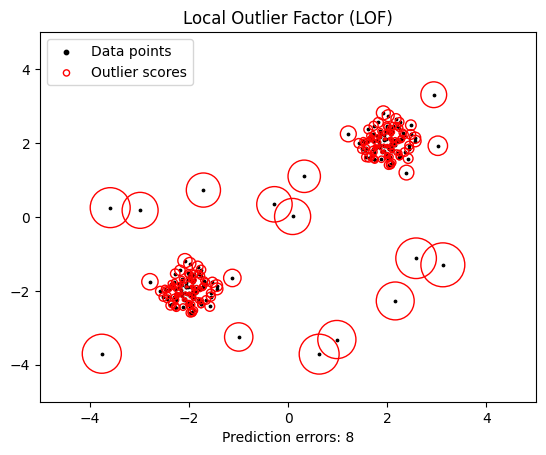

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# Generate train data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generate some outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

# Combine data
X = np.r_[X_inliers, X_outliers]
n_outliers = len(X_outliers)

# Ground truth
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1

# Fit the model for outlier detection
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

# Predict labels (-1 for outliers, 1 for inliers)
y_pred = clf.fit_predict(X)

# Count errors
n_errors = (y_pred != ground_truth).sum()

# LOF scores
X_scores = clf.negative_outlier_factor_

# Normalize scores for plotting radius
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

# Plot
plt.title("Local Outlier Factor (LOF)")

# Data points
plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Data points")

# Outlier scores visualization
plt.scatter(
    X[:, 0],
    X[:, 1],
    s=1000 * radius,
    edgecolors="r",
    facecolors="none",
    label="Outlier scores"
)

plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))

plt.xlabel(f"Prediction errors: {n_errors}")

legend = plt.legend(loc="upper left")

# Fix legend marker sizes
legend.legend_handles[0]._sizes = [10]
legend.legend_handles[1]._sizes = [20]

plt.show()